In [1]:
# Standard library
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Statistical tests
from scipy.stats import kruskal, mannwhitneyu, gaussian_kde
import scipy.stats as stats

# Project-local setup
sys.path.append("../src")
from plot_style import set_project_style, COLOR_DARK, COLOR_ACCENT, COLOR_BG, COLOR_BLUE, COLOR_GRAY

set_project_style()
data_dir = Path("../data/processed")

In [ ]:
# Setup: load clustered patient table

# Load the full clustered cohort (all 1763 patients, all three clusters)
df = pd.read_parquet("../data/processed/patient_features_clustered.parquet")
df = df.reset_index()  # PATIENT becomes a regular column

# Full cohort IDs for medication extraction
cohort_ids = set(df["PATIENT"].values)

print("Cohort size:", len(cohort_ids))
print("Cluster distribution:\n", df["cluster_label"].value_counts())

Cohort size: 1763
Cluster distribution:
 cluster_label
Mild, lower treatment intensity      1303
Multimorbid, high care complexity     366
Dyslipidemic / metabolic               94
Name: count, dtype: int64


In [ ]:
# [Step 1]: Chunked extraction of antidiabetic medication
# durations from medications.csv

# Drug class CODE mapping (exact codes from Phase 2 notebook 01 output)
code_to_class = {
    860975: "metformin",
    106892: "insulin",
    311034: "insulin",
    865098: "insulin",      # Humalog -- 4 patients, included for completeness
    897122: "other_antidiabetic",
    1373463: "other_antidiabetic"
}
antidiabetic_codes = set(code_to_class.keys())

# Chunked read -- same pattern as Phase 2 observations.csv extraction
chunk_size = 500_000
chunks = []

for chunk in pd.read_csv(
    "../data/csv/medications.csv",
    usecols=["PATIENT", "CODE", "START", "STOP"],
    chunksize=chunk_size,
    dtype={"CODE": "Int64"}  # nullable integer to handle any NaN before filtering
):
    mask = (
        chunk["PATIENT"].isin(cohort_ids) &
        chunk["CODE"].isin(antidiabetic_codes)
    )
    if mask.any():
        chunks.append(chunk[mask])

meds_raw = pd.concat(chunks, ignore_index=True)
meds_raw["CODE"] = meds_raw["CODE"].astype(int)  # back to standard int after concat

print(f"Rows extracted: {len(meds_raw)}")
print(f"Patients covered: {meds_raw['PATIENT'].nunique()}")
meds_raw.head()

Rows extracted: 85605
Patients covered: 1247


,START,STOP,PATIENT,CODE
0,2024-02-28T07:21:46Z,2024-04-03T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892
1,2024-04-03T07:21:46Z,2024-05-22T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892
2,2024-05-22T07:21:46Z,2024-06-19T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892
3,2024-06-19T07:21:46Z,2024-07-31T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892
4,2024-07-31T07:21:46Z,2024-08-07T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892


In [ ]:
# [Step 2]: Calculate per-patient total days on therapy

# Parse dates (ISO format with timezone)
meds_raw["START"] = pd.to_datetime(meds_raw["START"], utc=True)
meds_raw["STOP"]  = pd.to_datetime(meds_raw["STOP"],  utc=True)

# Reference date for still-active prescriptions (STOP = NaN):
# latest START in the extracted dataset as proxy for Synthea simulation end.
# Conservative: does not inflate duration of ongoing prescriptions.
ref_date = meds_raw["START"].max()
print("Reference date (simulation end proxy):", ref_date.date())

# Fill missing STOP, compute duration in days
meds_raw["STOP_filled"] = meds_raw["STOP"].fillna(ref_date)
meds_raw["duration_days"] = (
    (meds_raw["STOP_filled"] - meds_raw["START"])
    .dt.total_seconds() / 86400
).clip(lower=0)

# Map CODE -> drug class
meds_raw["drug_class"] = meds_raw["CODE"].map(code_to_class)

# Sum durations per patient per drug class, then total across all classes
duration_by_class = (
    meds_raw
    .groupby(["PATIENT", "drug_class"])["duration_days"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

duration_by_class["treatment_days_total"] = (
    duration_by_class[
        [c for c in ["metformin", "insulin", "other_antidiabetic"]
         if c in duration_by_class.columns]
    ].sum(axis=1)
)

print("\nShape:", duration_by_class.shape)
print("\ntreatment_days_total distribution:")
print(duration_by_class["treatment_days_total"].describe().round(1))
duration_by_class.head()

Reference date (simulation end proxy): 2026-06-15

Shape: (1247, 5)

treatment_days_total distribution:
count     1247.0
mean      5330.8
std       5668.3
min          0.0
25%       2509.5
50%       3763.2
75%       6277.1
max      46383.8
Name: treatment_days_total, dtype: float64


drug_class,PATIENT,insulin,metformin,other_antidiabetic,treatment_days_total
0,0003c6da-971f-a2b1-8693-4c1a27f98985,3706.606470,0.000000,0.000000,3706.606470
1,0005fc0b-a254-8215-d848-1a20685b750f,0.000000,3657.248356,0.000000,3657.248356
2,0012304f-0715-b5e9-efa2-ee32e57cfb57,0.000000,3466.020937,0.000000,3466.020937
3,00681a7d-5dad-ecfe-af77-b65f8da3fa15,0.000000,3705.992569,0.000000,3705.992569
4,007624da-0aa5-4f25-4dc5-ae157d27cd46,246.295556,246.295556,246.295556,738.886667


In [ ]:
# [Step 3]: Merge score with clustered cohort

# Left join: all 1763 cohort patients kept; those not in duration_by_class
# (no antidiabetic medication recorded) receive 0 for all drug class columns
df_scores = df.merge(
    duration_by_class[["PATIENT", "metformin", "insulin",
                        "other_antidiabetic", "treatment_days_total"]],
    on="PATIENT",
    how="left"
).fillna(0)

# Sanity check: cohort size preserved and zero-medication patients accounted for
print("Total patients:", len(df_scores))
print("Patients with treatment_days_total == 0:",
      (df_scores["treatment_days_total"] == 0).sum())
print("\nMean treatment_days_total by cluster:")
print(df_scores.groupby("cluster_label")["treatment_days_total"].mean().round(1))

Total patients: 1763
Patients with treatment_days_total == 0: 569

Mean treatment_days_total by cluster:
cluster_label
Dyslipidemic / metabolic             5032.1
Mild, lower treatment intensity      2401.3
Multimorbid, high care complexity    8321.3
Name: treatment_days_total, dtype: float64


**Treatment management modality: pharmacological vs. non-pharmacological**

The merged dataset reveals that 569 out of 1763 cohort patients (32.3%) have
`treatment_days_total = 0`, no antidiabetic medication recorded in `medications.csv`
for any of the six drug codes identified in Phase 2.

In a real-world T2D cohort, this subgroup most plausibly represents patients managed
through **non-pharmacological interventions** (diet, lifestyle modification, weight
management), a recognized and clinically valid first-line management strategy,
particularly in newly diagnosed patients with mild hyperglycemia or in those achieving
glycemic targets through behavioral change alone.

Including these patients in a treatment *intensity* or *adherence* analysis would be
conceptually incorrect: a score of zero days does not mean "low adherence", it means
"a different treatment modality altogether." Mixing the two groups would compress the
entire pharmacological gradient into the upper portion of the distribution and distort
all subsequent comparisons.

**Decision**: patients with `treatment_days_total = 0` are excluded from all treatment
intensity analyses in this notebook. They are treated as a distinct subgroup and
characterized separately (see plot below). The analytical dataset for intensity scoring
is restricted to the 1194 patients with at least one recorded antidiabetic prescription
(`treatment_days_total > 0`).

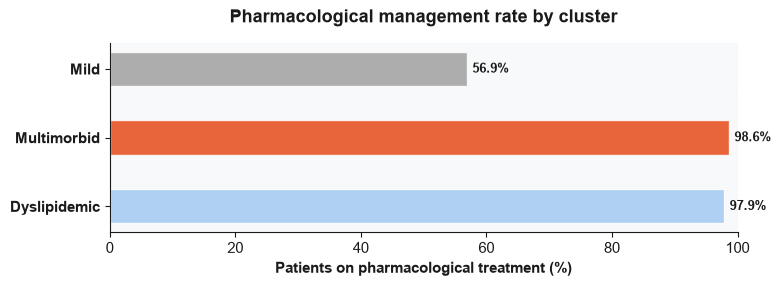


Raw counts:
  Mild: 741/1303 (56.9%)
  Multimorbid: 361/366 (98.6%)
  Dyslipidemic: 92/94 (97.9%)


In [ ]:
# Flag: pharmacological management (at least one antidiabetic prescription recorded)
df_scores["pharmacological"] = df_scores["treatment_days_total"] > 0

# Percentage per cluster
pharma_pct = (
    df_scores.groupby("cluster_label")["pharmacological"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .reset_index()
)
pharma_pct = pharma_pct[pharma_pct["pharmacological"] == False].copy()
pharma_pct["pct_pharma"] = 100 - pharma_pct["percentage"]

# Centralized color map
ordered_presentation_list = ["Dyslipidemic", "Multimorbid", "Mild"]

cluster_label_mapping = {
    "Mild": "Mild, lower treatment intensity",
    "Multimorbid": "Multimorbid, high care complexity",
    "Dyslipidemic": "Dyslipidemic / metabolic",
}

cluster_colors = {
    "Mild": COLOR_GRAY,
    "Multimorbid": COLOR_ACCENT,
    "Dyslipidemic": COLOR_BLUE,
}

fig, ax = plt.subplots(figsize=(8, 3))

# Build the Ordered Bar Chart
for i, presentation_label in enumerate(ordered_presentation_list):
    raw_label = cluster_label_mapping[presentation_label]

    pct = pharma_pct.loc[
        pharma_pct["cluster_label"] == raw_label, "pct_pharma"
    ].values[0]

    color = cluster_colors[presentation_label]

    ax.barh(i, pct, color=color, alpha=0.85, height=0.5)

    # By setting clip_on=False, text labels are allowed to render outside the ax limits
    ax.annotate(
        f"{pct:.1f}%",
        xy=(pct, i),
        xytext=(4, 0),
        textcoords="offset points",
        fontsize=9,
        color=COLOR_DARK,
        va="center",
        fontweight="bold",
        clip_on=False,
    )

# Axis Formatting and Styling
ax.set_yticks(range(len(ordered_presentation_list)))
ax.set_yticklabels(ordered_presentation_list, fontweight="bold")

# Force the X-axis limit to end precisely at 100
ax.set_xlim(0, 100)
ax.set_xlabel("Patients on pharmacological treatment (%)", weight="bold")
ax.set_title("Pharmacological management rate by cluster", pad=15, weight="bold")
ax.axvline(100, color="#b0aea5", linewidth=0.8, linestyle="--", alpha=0.5)

# Adjust the subplots with a specific right margin padding to prevent 
# window-level clipping on the final exported canvas view
plt.tight_layout()
fig.subplots_adjust(right=0.93)
plt.show()

# Print Raw Counts for Markdown
print("\nRaw counts:")
for presentation_label in ordered_presentation_list[::-1]:
    raw_label = cluster_label_mapping[presentation_label]
    sub = df_scores[df_scores["cluster_label"] == raw_label]
    n_pharma = sub["pharmacological"].sum()
    n_total = len(sub)
    print(
        f"  {presentation_label}: {n_pharma}/{n_total} ({100*n_pharma/n_total:.1f}%)"
    )

**Pharmacological management rate by cluster**: the three clusters differ sharply in
the proportion of patients receiving pharmacological treatment.

- **Multimorbid** (361/366, 98.6%) and **Dyslipidemic** (92/94, 97.9%): near-universal
  pharmacological management, consistent with their clinical profiles. Multimorbid
  patients carry the highest disease burden (CCI 4.34, Phase 3) and are almost
  exclusively on insulin; Dyslipidemic patients present a pronounced metabolic
  dysregulation that systematically requires pharmacological intervention.
- **Mild** (741/1303, 56.9%): only about half the cluster is on pharmacological
  treatment. The remaining 562 patients (43.1%) are managed through non-pharmacological
  means, diet, lifestyle modification, or watchful waiting, a clinically expected
  finding for a cluster defined by low disease burden and glycemic values closer to
  target (mean HbA1c 6.09, Phase 3).

This distribution reinforces the clinical validity of the Phase 3 cluster labels and
motivates the exclusion of zero-treatment patients from the intensity analysis below:
their `treatment_days_total = 0` reflects a different management modality, not low
adherence to pharmacological therapy.

In [ ]:
# [Step 3c]: restrict analytical dataset to
# pharmacologically managed patients for all subsequent intensity analyses

df_pharma = df_scores[df_scores["treatment_days_total"] > 0].copy()

print(f"Analytical dataset: {len(df_pharma)} patients "
      f"({len(df_pharma)/len(df_scores)*100:.1f}% of full cohort)")
print("\nBy cluster:")
print(df_pharma["cluster_label"].value_counts())

Analytical dataset: 1194 patients (67.7% of full cohort)

By cluster:
cluster_label
Mild, lower treatment intensity      741
Multimorbid, high care complexity    361
Dyslipidemic / metabolic              92
Name: count, dtype: int64


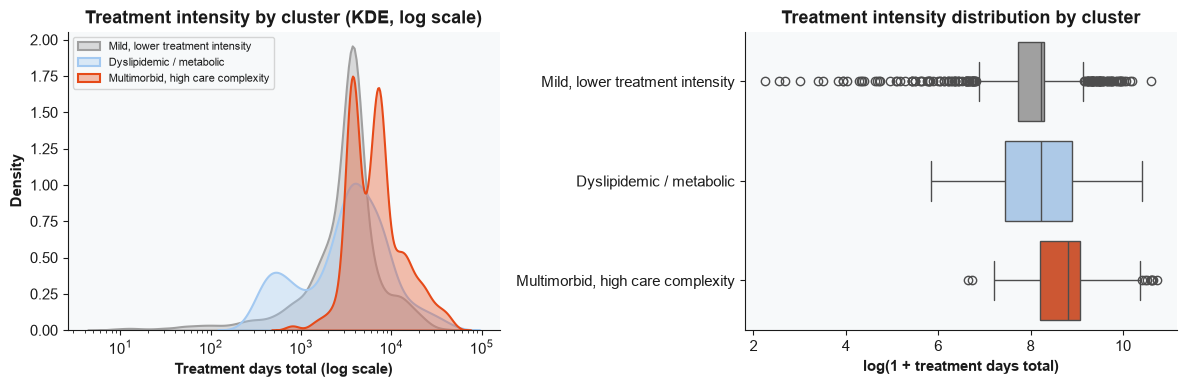

In [ ]:
# [Step 4]: KDE instead of histogram for left panel

# Log-transform for visualization only: the raw distribution is heavily right-skewed
# (std 5668 >> mean 5330, max ~46000). log1p (log(x+1)) handles the zero values
# from untreated patients gracefully (log1p(0) = 0).
df_pharma["treatment_days_log"] = np.log1p(df_pharma["treatment_days_total"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: KDE per cluster, log-scaled x-axis
# bw_adjust=0.8 slightly tightens the bandwidth vs default (1.0) -- the log-scale
# spread is large enough that the default can over-smooth meaningful peaks
# fill=True adds a light shaded area under each curve for easier visual separation
for label in cluster_order:
    subset = df_pharma.loc[
        df_pharma["cluster_label"] == label, "treatment_days_total"
    ]
    # exclude zeros (untreated patients) from KDE: log(0) is undefined and they
    # would create a separate spike at the left edge that distorts the shape
    subset_nonzero = subset[subset > 0]
    sns.kdeplot(
        subset_nonzero,
        ax=axes[0],
        label=label,
        color=cluster_colors[label],
        fill=True,
        alpha=0.35,
        linewidth=1.5,
        bw_adjust=0.8,
        log_scale=True
    )

axes[0].set_xlabel("Treatment days total (log scale)")
axes[0].set_ylabel("Density")
axes[0].set_title("Treatment intensity by cluster (KDE, log scale)")
axes[0].legend(fontsize=8)

# Right: unchanged
sns.boxplot(
    data=df_pharma,
    x="treatment_days_log",
    y="cluster_label",
    hue="cluster_label",
    order=cluster_order,
    hue_order=cluster_order,
    palette=cluster_colors,
    legend=False,
    ax=axes[1]
)
axes[1].set_xlabel("log(1 + treatment days total)")
axes[1].set_ylabel("")
axes[1].set_title("Treatment intensity distribution by cluster")

plt.tight_layout()
plt.show()

In [ ]:
# [Step 5]: Statistical comparison across clusters

# Kruskal-Wallis: non-parametric omnibus test (appropriate given the heavily
# right-skewed distribution and presence of zeros -- normality not assumed)
groups = [
    df_pharma.loc[df_pharma["cluster_label"] == label, "treatment_days_total"].values
    for label in cluster_order
]
stat, p_kruskal = kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.1f}, p={p_kruskal:.2e}")

# Pairwise Mann-Whitney U tests (post-hoc, if Kruskal-Wallis is significant)
# No correction applied here (3 pairs, exploratory context)
pairs = [
    ("Mild, lower treatment intensity",   "Multimorbid, high care complexity"),
    ("Mild, lower treatment intensity",   "Dyslipidemic / metabolic"),
    ("Dyslipidemic / metabolic",          "Multimorbid, high care complexity")
]

print("\nPairwise Mann-Whitney U (two-sided):")
for a, b in pairs:
    x = df_pharma.loc[df_pharma["cluster_label"] == a, "treatment_days_total"]
    y = df_pharma.loc[df_pharma["cluster_label"] == b, "treatment_days_total"]
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    # Effect size r = Z / sqrt(N)
    z = stats.norm.ppf(p / 2)
    r = abs(z) / np.sqrt(len(x) + len(y))
    print(f"  {a.split(',')[0]} vs {b.split(',')[0]}: U={u:.0f}, p={p:.2e}, r={r:.3f}")

Kruskal-Wallis H=170.7, p=8.77e-38

Pairwise Mann-Whitney U (two-sided):
  Mild vs Multimorbid: U=68643, p=2.21e-39, r=0.396
  Mild vs Dyslipidemic / metabolic: U=32579, p=4.89e-01, r=0.024
  Dyslipidemic / metabolic vs Multimorbid: U=10450, p=3.99e-08, r=0.258


**Step 5, Statistical comparison of treatment intensity across clusters**

**Test**: Kruskal-Wallis (non-parametric omnibus, appropriate given the right-skewed
distribution of `treatment_days_total`), followed by pairwise Mann-Whitney U post-hoc
tests. All analyses restricted to pharmacologically managed patients (n=1194, `df_pharma`).

**Results**:

| Comparison | U statistic | p-value | Effect size r |
|---|---|---|---|
| Mild vs Multimorbid | 68,643 | 2.21e-39 | 0.396 (medium) |
| Mild vs Dyslipidemic | 32,579 | 4.89e-01 | 0.024 (negligible) |
| Dyslipidemic vs Multimorbid | 10,450 | 3.99e-08 | 0.258 (small-medium) |

Kruskal-Wallis: H=170.7, p=8.77e-38.

**Interpretation**: once the analysis is restricted to pharmacologically managed patients,
a striking result emerges, **Mild and Dyslipidemic are statistically indistinguishable
in treatment intensity** (p=0.49, r=0.024, negligible effect). Both clusters show similar
cumulative days on therapy (medians ~3708 and ~3751 days respectively), suggesting that
among patients who do receive pharmacological treatment, Dyslipidemic patients are managed
with similar persistence to Mild patients, the defining difference between these two
clusters is *metabolic profile* (lipid panel, Phase 3), not treatment duration.

The only statistically and practically meaningful separation is between **Multimorbid and
both other clusters**: Mild vs Multimorbid r=0.396 (medium effect), Dyslipidemic vs
Multimorbid r=0.258 (small-medium). Multimorbid patients accumulate nearly double the
treatment days of the other two groups (median 6729 vs ~3700 days), consistent with their
higher disease burden, older age, and almost universal insulin use (Phase 3 profile).

**Note**: these effect sizes are materially smaller than those estimated on the full cohort
including untreated patients (Mild vs Multimorbid r=0.505 on `df_scores`). The reduction
confirms that a substantial part of the apparent Mild/Multimorbid separation in the full
dataset was driven by the 43% of Mild patients with zero treatment days, a management
modality difference, not a treatment intensity difference among those actually treated.

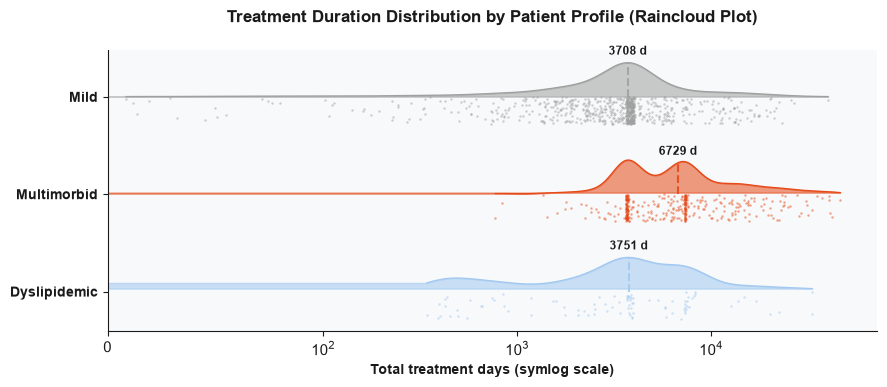

In [38]:
# [Step 6]: Raincloud summary plot

# A raincloud plot separates the distribution shape (half-violin, top half only)
# from the individual points (strip, below), avoiding overlap between the two.
# It's increasingly common in clinical/neuroscience publications as it shows
# both density and raw data without one obscuring the other.
# Implementation: use violinplot clipped to one side via a post-hoc Path patch,
# approximated here with a KDE + fill_between approach for full control.

fig, ax = plt.subplots(figsize=(9, 4))

# Explicitly order the list backwards so Matplotlib stacks them upwards:
# Index 0 (Bottom) = Dyslipidemic, Index 1 (Middle) = Multimorbid, Index 2 (Top) = Mild
ordered_presentation_list = ["Dyslipidemic", "Multimorbid", "Mild"]

# Internal technical mapping back to your dataframe's raw cluster labels
cluster_label_mapping = {
    "Mild": "Mild, lower treatment intensity",
    "Multimorbid": "Multimorbid, high care complexity",
    "Dyslipidemic": "Dyslipidemic / metabolic",
}

# Predefined color palette configurations
cluster_colors = {
    "Mild": COLOR_GRAY,
    "Multimorbid": COLOR_ACCENT,
    "Dyslipidemic": COLOR_BLUE,
}

# Build the Ordered Raincloud Plot
for i, presentation_label in enumerate(ordered_presentation_list):
    # Fetch raw cluster string name for dataframe queries
    raw_label = cluster_label_mapping[presentation_label]

    subset = df_pharma.loc[
        df_pharma["cluster_label"] == raw_label, "treatment_days_total"
    ].values
    color = cluster_colors[presentation_label]

    # KDE on log-transformed data for smoothness, then exponentiate back
    log_vals = np.log1p(subset)
    kde = gaussian_kde(log_vals, bw_method=0.25)
    x_log = np.linspace(log_vals.min(), log_vals.max(), 300)
    y_kde = kde(x_log)
    x_raw = np.expm1(x_log)

    # Normalize KDE height to 0.35 (half the inter-cluster spacing of 1.0)
    y_kde_norm = y_kde / y_kde.max() * 0.35

    # Half-violin: fill above the cluster baseline
    ax.fill_betweenx(i + y_kde_norm, x_raw, alpha=0.55, color=color)
    ax.plot(x_raw, i + y_kde_norm, color=color, linewidth=1)

    # Strip / Jitter plot directly below the baseline
    rng = np.random.default_rng(42)
    jitter = rng.uniform(-0.28, 0.0, size=len(subset))
    ax.scatter(
        subset,
        i + jitter,
        color=color,
        alpha=0.5,
        s=3,
        linewidths=0,
        zorder=2,
    )

    # Median marker: vertical dashed line from baseline to KDE peak surface
    median_val = np.median(subset)

    # Evaluate KDE height at the median point (in log space, then normalize)
    median_log = np.log1p(median_val)
    kde_at_median = kde(np.array([median_log]))[0]
    kde_at_median_norm = kde_at_median / y_kde.max() * 0.35

    ax.plot(
        [median_val, median_val],  # x: vertical line alignment at median point
        [i, i + kde_at_median_norm],  # y: spanning from baseline up to surface
        color=color,
        linewidth=1.5,
        linestyle="--",
        zorder=4,
        alpha=0.9,
    )

    ax.annotate(
        f"{median_val:.0f} d",
        xy=(median_val, i + kde_at_median_norm),
        xytext=(0, 4),  # 4pt offset spacing above the marker line
        textcoords="offset points",
        fontsize=8.5,
        color=COLOR_DARK,
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Axis Formatting and Labeling
ax.set_xscale("symlog", linthresh=100)
ax.set_xlim(left=0)
ax.set_xlabel("Total treatment days (symlog scale)", fontsize=10, weight="bold")
ax.set_ylabel("")

# Map ticks directly to match the top-to-bottom presentation sequence
ax.set_yticks(range(len(ordered_presentation_list)))
ax.set_yticklabels(ordered_presentation_list, fontsize=10, weight="bold")

ax.set_title(
    "Treatment Duration Distribution by Patient Profile (Raincloud Plot)",
    pad=20,
    fontsize=12,
    weight="bold",
)

plt.tight_layout()
plt.show()

In [34]:
# Export pharmacological subset and full scores for report figures notebook
df_pharma[["cluster_label", "treatment_days_total"]].to_csv(data_dir / "df_pharma.csv", index=False)
df_scores[["cluster_label", "treatment_days_total"]].to_csv(data_dir / "df_scores.csv", index=False)

**Conclusion — Treatment adherence/intensity score (exploratory extension)**

**Motivation**: this notebook extends the qualitative finding from notebook 03, a
metformin-associated metabolic gradient within Cluster 0 (Mild), by constructing a
quantitative, continuous treatment intensity score (total antidiabetic drug days,
summed across all prescribed classes) and examining its distribution across all three
Phase 3 subtypes.

**Key findings**:

1. **Management modality varies sharply by cluster**: 98.6% of Multimorbid and 97.9% of
   Dyslipidemic patients are on pharmacological treatment, vs. only 56.9% of Mild
   patients. The 43.1% of Mild patients managed non-pharmacologically (diet/lifestyle)
   represent a clinically coherent subgroup, excluded from intensity analysis to avoid
   conflating treatment modality with treatment adherence.

2. **Among pharmacologically managed patients, only Multimorbid is meaningfully more
   intense**: Mild and Dyslipidemic have near-identical treatment duration distributions
   (medians ~3708 and ~3751 days, p=0.49, r=0.024). Multimorbid patients accumulate
   nearly double the treatment days (median 6729 days, r=0.396 vs Mild, r=0.258 vs
   Dyslipidemic), consistent with higher disease burden and near-universal insulin use.

3. **The metformin gradient in Cluster 0 (notebook 03) is better explained by management
   modality than by treatment intensity**: within the pharmacologically managed Mild
   subgroup, the treatment duration distribution is broad and right-skewed, consistent
   with the continuous gradient identified in notebook 03 rather than a discrete
   sub-phenotype.

**Limitations**: total days on therapy conflates treatment duration with disease history
length, patients diagnosed earlier accumulate more days regardless of adherence. A more
precise score would normalize by time since diagnosis, which was not available as a clean
single-date variable in the Synthea output. The extreme outlier (max ~46,000 days, ~127
years) is almost certainly a data generation artifact (open-ended prescription with an
early START date), retained in the dataset but noted as a known limitation.

**Relation to Phase 4**: this score was deliberately not incorporated into the Phase 4
predictive model, which follows a treatment-naive design. It remains a descriptive,
exploratory finding, a candidate feature for a future treatment-aware model variant if
the treatment-naive framing is relaxed.